In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
or_threshold_pheno = 0.95
or_threshold_anno = 0.95

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""conservation""","""mamphylop""","""#942c80""","""Mammalian PhyloP""",1
"""splicing""","""pangolin_score""","""#28a745""","""Pangolin""",1
"""splicing""","""delta_score""","""#28a745""","""SpliceAI""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
# existing_annos += ['five_prime_utr_variant_consequence_uaug_gained', 'five_prime_utr_variant_consequence_uaug_lost', 'five_prime_utr_variant_consequence_uframeshift', 'five_prime_utr_variant_consequence_ustop_gained', 'five_prime_utr_variant_consequence_ustop_lost']

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "intronic"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        filter_expression &
        (
            (pl.col('consequence_splice_donor_variant') == 0) &
            (pl.col('consequence_splice_acceptor_variant') == 0) &
            (pl.col('consequence_splice_region_variant') == 0) &
            (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
            (pl.col('consequence_splice_donor_region_variant') == 0) &
            (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        ) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

am_pathogenicity,esmscoremissense,gene_name,region,pangolin_score,delta_score,cadd_raw,verphylop,Strand,id,absplice_dna_max,mamphylop,gpn_score,TSS,loftee_hc,gpn_star_llr_calibrated_mean,gene_length,dist_to_tss,absplice2_max
f32,f32,str,str,f32,f32,f32,f32,cat,str,f32,f32,f32,i64,i8,f64,i64,i64,f32
0.0,0.0,"""LRP2""","""ENSG00000081479""",0.0,0.0,0.466688,0.217,"""-""","""chr2:169197167:T:G""",0.001,0.774,-1.5,169362534,0,0.153293,235427,165367,0.000033
0.0,0.0,"""LRP2""","""ENSG00000081479""",0.0,0.01,0.104863,0.291,"""-""","""chr2:169204292:A:T""",0.003,0.085,-0.63,169362534,0,1.684965,235427,158242,0.000116
0.0,0.0,"""ABCB11""","""ENSG00000073734""",0.0,0.0,0.326902,0.023,"""-""","""chr2:169030531:C:T""",0.001,0.015,-1.64,169031324,0,-1.212965,115828,793,0.000033
0.0,0.0,"""ABCB11""","""ENSG00000073734""",0.0,0.0,-0.070862,0.193,"""-""","""chr2:169007174:C:T""",0.001,0.19,0.08,169031324,0,-0.238119,115828,24150,0.000033
0.0,0.0,"""LRP2""","""ENSG00000081479""",0.0,0.0,0.211538,0.117,"""-""","""chr2:169175752:G:A""",0.001,0.117,-0.98,169362534,0,-1.768037,235427,186782,0.000033
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,"""CD200""","""ENSG00000091972""",0.0,0.0,-0.577349,-1.497,"""+""","""chr3:112365432:T:C""",0.0,-1.553,1.12,112332346,0,0.631638,30467,33086,0.0
0.0,0.0,"""CD200""","""ENSG00000091972""",0.0,0.0,0.73253,-0.052,"""+""","""chr3:112330089:T:G""",0.0,-0.073,-4.13,112332346,0,0.406711,30467,-2257,0.0
0.0,0.0,"""CD200""","""ENSG00000091972""",0.0,0.0,0.636473,0.407,"""+""","""chr3:112329326:T:C""",0.0,0.392,-1.89,112332346,0,-1.380881,30467,-3020,0.0


In [4]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )
    # .filter( 
    #     pl.col('annotation_score_dircor_ptile') > or_threshold_anno
    # )

    # Filter based on category
    .filter(
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:169197167:T:G""","""ENSG00000081479""","""cadd_raw""",0.466688,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.466688,54801.0,77345,0.708527
"""chr2:169204292:A:T""","""ENSG00000081479""","""cadd_raw""",0.104863,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.104863,26432.0,77345,0.341742
"""chr2:169030531:C:T""","""ENSG00000073734""","""cadd_raw""",0.326902,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.326902,21379.0,36474,0.586144
"""chr2:169007174:C:T""","""ENSG00000073734""","""cadd_raw""",-0.070862,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.070862,6661.0,36474,0.182623
"""chr2:169175752:G:A""","""ENSG00000081479""","""cadd_raw""",0.211538,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.211538,35476.0,77345,0.458672
…,…,…,…,…,…,…,…,…,…,…,…
"""chr3:112365432:T:C""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1700.5,13798,0.123242
"""chr3:112330089:T:G""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1700.5,13798,0.123242
"""chr3:112329326:T:C""","""ENSG00000091972""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1700.5,13798,0.123242


In [5]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [6]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Debug

In [ ]:
gene_trait_df = gene_trait_df.filter(
    pl.col('gene_name') == "LDLR",
    pl.col('phenotype') == "ldl_direct_int",
)
gene_trait_df

In [7]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_ptile = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_ptile = (
    gp_ptile
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
    .collect(engine='streaming')
)

or_ptile

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9505,23,410,405,7717,1.068901
"""delta_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.951,22,363,406,7764,1.158979
"""absplice2_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.951,31,405,397,7722,1.488833
"""pangolin_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.952,17,291,411,7836,1.113803
"""absplice2_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.953,31,392,397,7735,1.540797
…,…,…,…,…,…,…,…,…,…
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.996,2,38,426,8089,0.999382
"""absplice2_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.996,4,31,424,8096,2.463786
"""absplice_dna_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9965,2,31,426,8096,1.226109


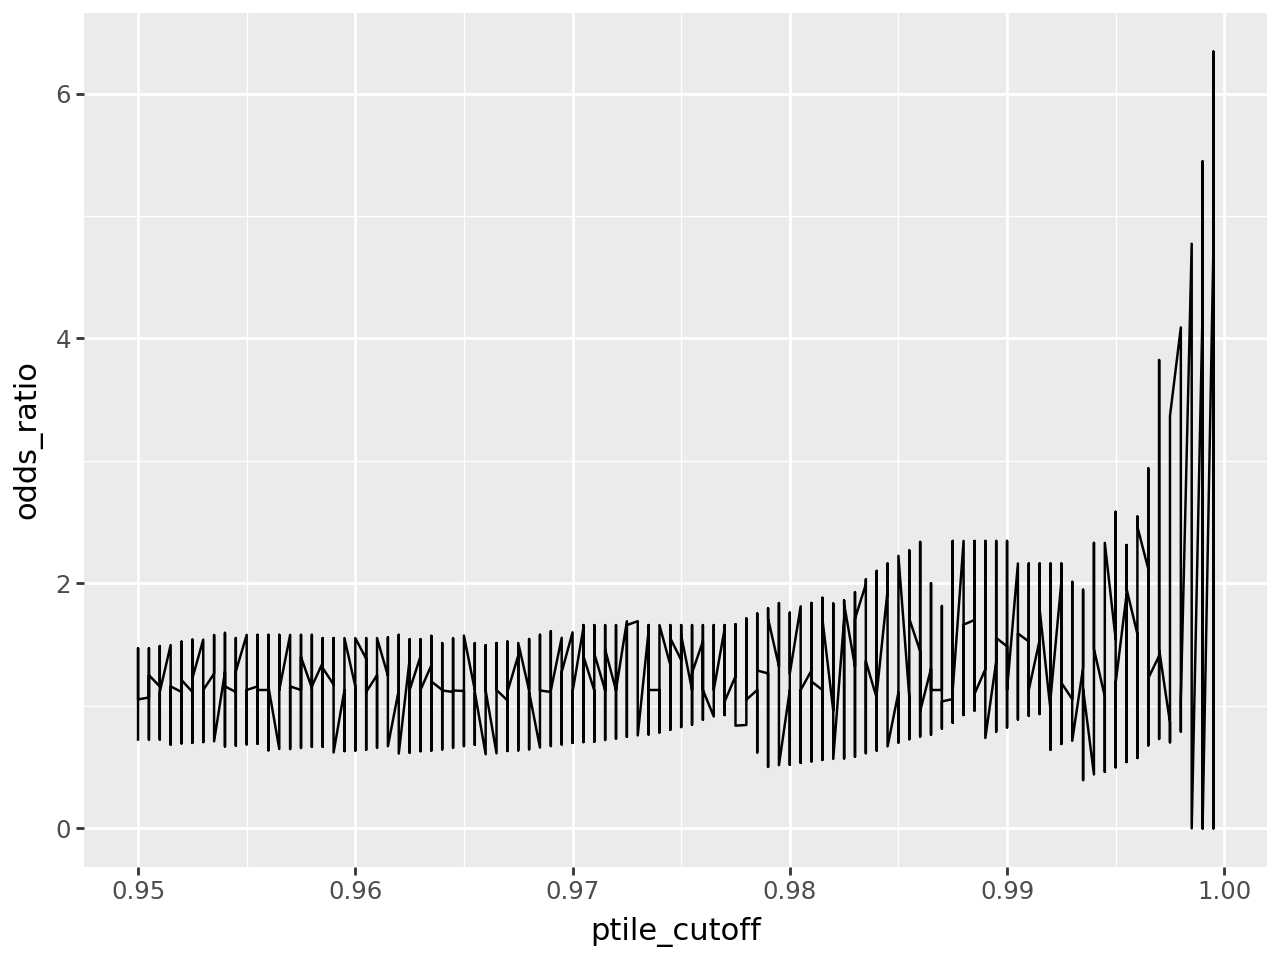

In [8]:
(
    ggplot(
        or_ptile,
        aes(x='ptile_cutoff', y='odds_ratio')
    )
    + geom_line()
)

## Resume code

In [7]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')
or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""absplice_dna_max""","""ENSG00000024048""","""UBR2""","""arm_fat_mass_right_int""",0.95,18,258,1208,22395,1.293412
"""pangolin_score""","""ENSG00000159899""","""NPR2""","""basal_metabolic_rate_int""",0.95,2,122,132,2246,0.278937
"""cadd_raw""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,7,130,122,2487,1.097667
"""pangolin_score""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,3,105,126,2512,0.569615
"""delta_score""","""ENSG00000132855""","""ANGPTL3""","""cholesterol_int""",0.95,4,40,46,952,2.069565
…,…,…,…,…,…,…,…,…,…
"""pangolin_score""","""ENSG00000152270""","""PDE3B""","""whole_body_water_mass_int""",0.9995,1,20,2603,48220,0.926239
"""gpn_star_llr_calibrated_mean""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",0.9995,2,38,3857,71606,0.977116
"""pangolin_score""","""ENSG00000157766""","""ACAN""","""whole_body_water_mass_int""",0.9995,1,7,801,14648,2.612449


In [8]:
or_df.filter(pl.col('n_dis_above_cutoff')>0)

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""absplice_dna_max""","""ENSG00000024048""","""UBR2""","""arm_fat_mass_right_int""",0.95,18,258,1208,22395,1.293412
"""pangolin_score""","""ENSG00000159899""","""NPR2""","""basal_metabolic_rate_int""",0.95,2,122,132,2246,0.278937
"""cadd_raw""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,7,130,122,2487,1.097667
"""pangolin_score""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,3,105,126,2512,0.569615
"""delta_score""","""ENSG00000132855""","""ANGPTL3""","""cholesterol_int""",0.95,4,40,46,952,2.069565
…,…,…,…,…,…,…,…,…,…
"""absplice_dna_max""","""ENSG00000182752""","""PAPPA""","""whole_body_water_mass_int""",0.9995,3,25,2691,48489,2.162274
"""pangolin_score""","""ENSG00000152270""","""PDE3B""","""whole_body_water_mass_int""",0.9995,1,20,2603,48220,0.926239
"""gpn_star_llr_calibrated_mean""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",0.9995,2,38,3857,71606,0.977116


In [ ]:
# or_df.write_parquet('/home/dnanexus/data_dir/odds_ratio_deep_intronic_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df = pl.read_parquet('/home/dnanexus/data_dir/odds_ratio_deep_intronic_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""absplice_dna_max""","""ENSG00000024048""","""UBR2""","""arm_fat_mass_right_int""",0.95,18,258,1208,22395,1.293412
"""pangolin_score""","""ENSG00000159899""","""NPR2""","""basal_metabolic_rate_int""",0.95,2,122,132,2246,0.278937
"""cadd_raw""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,7,130,122,2487,1.097667
"""pangolin_score""","""ENSG00000167676""","""PLIN4""","""body_fat_percentage_int""",0.95,3,105,126,2512,0.569615
"""delta_score""","""ENSG00000132855""","""ANGPTL3""","""cholesterol_int""",0.95,4,40,46,952,2.069565
…,…,…,…,…,…,…,…,…,…
"""pangolin_score""","""ENSG00000152270""","""PDE3B""","""whole_body_water_mass_int""",0.9995,1,20,2603,48220,0.926239
"""gpn_star_llr_calibrated_mean""","""ENSG00000140443""","""IGF1R""","""whole_body_water_mass_int""",0.9995,2,38,3857,71606,0.977116
"""pangolin_score""","""ENSG00000157766""","""ACAN""","""whole_body_water_mass_int""",0.9995,1,7,801,14648,2.612449


In [14]:
(
    or_df
    .filter(~pl.col("odds_ratio").is_finite())
    # .with_columns(
    #     odds_ratio_new = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    # )
    # .filter(pl.col("odds_ratio_new").is_finite())
)

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""delta_score""","""ENSG00000121853""","""GHSR""","""sitting_height_int""",0.95,0,0,19,379,NaN
"""absplice2_max""","""ENSG00000164741""","""DLC1""","""standing_height_int""",0.95,0,0,8375,152174,NaN
"""absplice_dna_max""","""ENSG00000121853""","""GHSR""","""whole_body_fatfree_mass_int""",0.95,0,0,25,371,NaN
"""absplice_dna_max""","""ENSG00000151914""","""DST""","""arm_fatfree_mass_left_int""",0.95,0,0,5047,91121,NaN
"""pangolin_score""","""ENSG00000121853""","""GHSR""","""sitting_height_int""",0.95,0,0,19,379,NaN
…,…,…,…,…,…,…,…,…,…
"""delta_score""","""ENSG00000145386""","""CCNA2""","""whole_body_fatfree_mass_int""",0.9995,0,0,47,876,NaN
"""absplice_dna_max""","""ENSG00000178252""","""WDR6""","""whole_body_water_mass_int""",0.9995,0,0,56,1018,NaN
"""mamphylop""","""ENSG00000121853""","""GHSR""","""whole_body_water_mass_int""",0.9995,0,0,26,370,NaN


In [12]:
plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['ptile_cutoff', 'annotation']),
        med_odds_ratio = pl.col('odds_ratio').median().over(['ptile_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        std_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('std_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('std_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'std_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)
plt_df

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""cadd_raw""",0.95,1144,1.075306,1.149707,0.861366,2.837985,-0.538571,"""#1f77b4""","""CADD Raw"""
"""absplice2_max""",0.95,1123,1.02132,1.106848,0.740597,2.558418,-0.344722,"""#28a745""","""AbSplice2 (max)"""
"""gpn_score""",0.95,1145,1.104082,1.143995,0.563038,2.247549,0.04044,"""#942c80""","""GPN-MSA"""
"""gpn_star_llr_calibrated_mean""",0.95,1145,1.113468,1.16712,0.588359,2.320305,0.013936,"""#942c80""","""GPN-Star"""
"""absplice_dna_max""",0.95,1119,1.041492,1.140857,0.711308,2.535021,-0.253307,"""#28a745""","""AbSplice (max)"""
…,…,…,…,…,…,…,…,…,…
"""mamphylop""",0.9995,899,0.0,1.430038,3.324104,7.945283,-5.085206,"""#942c80""","""Mammalian PhyloP"""
"""absplice2_max""",0.9995,1026,0.0,1.841346,5.952279,13.507812,-9.82512,"""#28a745""","""AbSplice2 (max)"""
"""cadd_raw""",0.9995,1088,0.0,1.767746,5.382146,12.316752,-8.78126,"""#1f77b4""","""CADD Raw"""


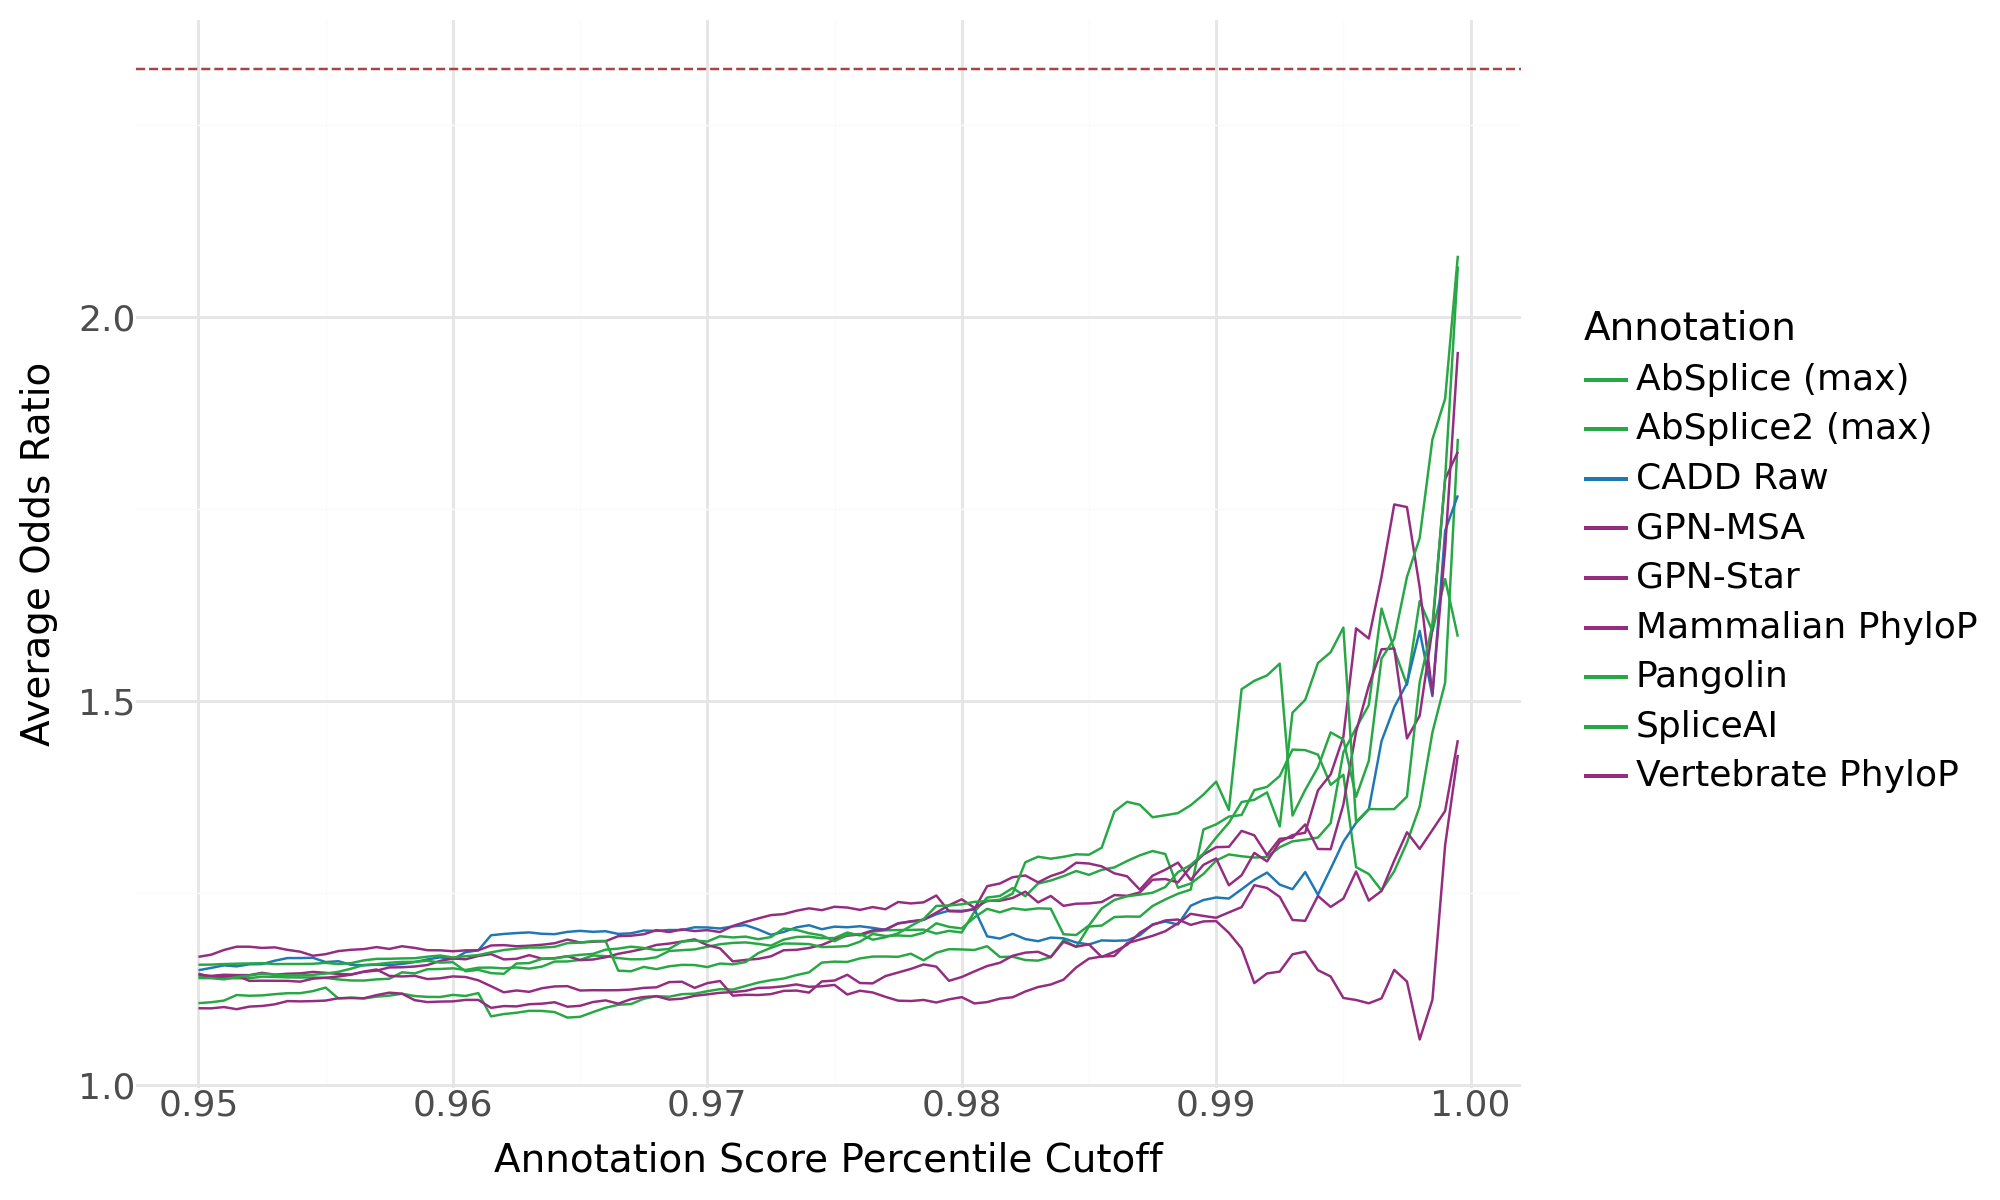

In [24]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))


am_lof_or_mean = {
    'loftee_all': 9.998645,
    'am_all': 3.628273,
    'loftee_coding': 6.874422,
    'am_coding': 2.323273
}

am_lof_or_median = {
    'loftee_all': 3.573782,
    'am_all': 2.027029,
    'loftee_coding': 3.04127,
    'am_coding': 1.770242
}

(
    ggplot(
        plt_df,
        aes(x='ptile_cutoff', y='avg_odds_ratio', color='label')
        # aes(x='ptile_cutoff', y='med_odds_ratio', color='label')
    )
    + geom_line()
    # + geom_hline(aes(yintercept=am_lof_or_mean['loftee_coding']), linetype='dashed', color='black')
    + geom_hline(aes(yintercept=am_lof_or_mean['am_coding']), linetype='dashed', color='#AA4344')
    # + geom_hline(aes(yintercept=am_lof_or_median['loftee']), linetype='dashed', color='black')
    # + geom_hline(aes(yintercept=am_lof_or_median['am']), linetype='dashed', color='#AA4344')
    # + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.2)
    # + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio",
        x="Annotation Score Percentile Cutoff",
        color="Annotation",
    )
    # + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=14),
        legend_text=element_text(size=13),
        legend_title=element_text(size=14),
    )
)

In [22]:
plt_df.sort('avg_odds_ratio', descending=True)

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""delta_score""",0.9995,1041,0.0,2.079615,5.986886,13.813911,-9.654682,"""#28a745""","""SpliceAI"""
"""pangolin_score""",0.9995,1016,0.0,2.065624,6.765206,15.325427,-11.194179,"""#28a745""","""Pangolin"""
"""gpn_star_llr_calibrated_mean""",0.9995,1059,0.0,1.95449,7.776419,17.196271,-13.28729,"""#942c80""","""GPN-Star"""
"""delta_score""",0.999,1072,0.713928,1.89356,3.885715,9.509561,-5.72244,"""#28a745""","""SpliceAI"""
"""absplice2_max""",0.9995,1026,0.0,1.841346,5.952279,13.507812,-9.82512,"""#28a745""","""AbSplice2 (max)"""
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""",0.962,1123,1.024172,1.092642,0.601984,2.272531,-0.087247,"""#28a745""","""AbSplice2 (max)"""
"""absplice2_max""",0.9615,1123,1.024172,1.089615,0.600622,2.266834,-0.087605,"""#28a745""","""AbSplice2 (max)"""
"""absplice2_max""",0.965,1123,1.025089,1.089037,0.600343,2.265709,-0.087634,"""#28a745""","""AbSplice2 (max)"""


In [20]:
plt_df.filter(pl.col('avg_odds_ratio') >= am_lof_or_mean['loftee_coding']).sort('ptile_cutoff').head()

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str


In [48]:
melted_anno.filter(
    (pl.col('annotation') == 'absplice_dna_max') &
    (pl.col('annotation_score_dircor_ptile')>0.9975)
)['id'].n_unique()

35097

In [49]:
plt_df.filter(pl.col('ptile_cutoff') == 0.9999).sort('avg_odds_ratio', descending=True)

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,std_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""mamphylop""",0.9999,1137,50.0,66.442999,33.940299,132.965985,-0.079987,"""#942c80""","""Mammalian PhyloP"""
"""verphylop""",0.9999,1138,50.0,48.616261,31.421608,110.202612,-12.97009,"""#942c80""","""Vertebrate PhyloP"""
"""gpn_star_llr_calibrated_mean""",0.9999,1144,50.0,47.29359,28.518187,103.189236,-8.602056,"""#942c80""","""GPN-Star"""
"""gpn_score""",0.9999,1141,50.0,46.399792,26.79529,98.91856,-6.118976,"""#942c80""","""GPN-MSA"""
"""absplice_dna_max""",0.9999,1117,33.333333,46.053178,27.917951,100.772362,-8.666007,"""#28a745""","""AbSplice (max)"""
"""absplice2_max""",0.9999,1123,33.333333,44.947108,27.672808,99.185812,-9.291595,"""#28a745""","""AbSplice2 (max)"""
"""pangolin_score""",0.9999,1116,33.333333,44.703661,27.736122,99.06646,-9.659138,"""#28a745""","""Pangolin"""
"""cadd_raw""",0.9999,1144,50.0,43.897705,25.954149,94.767837,-6.972427,"""#1f77b4""","""CADD Raw"""
"""delta_score""",0.9999,1116,33.333333,43.377289,26.199187,94.727697,-7.973118,"""#28a745""","""SpliceAI"""
